<a href="https://colab.research.google.com/github/chaupham31251020816-png/Homework2/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bài 2.11

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.7 MB/s eta 0:00:00


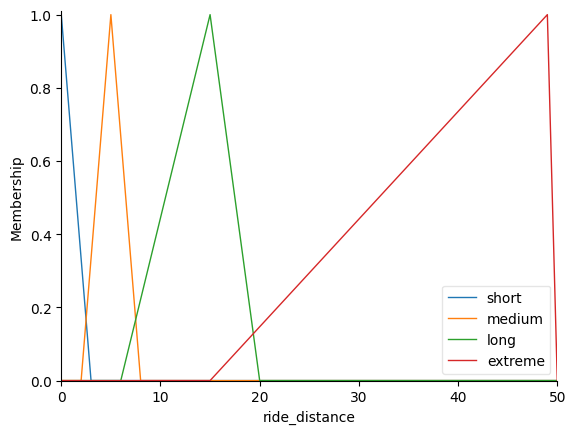

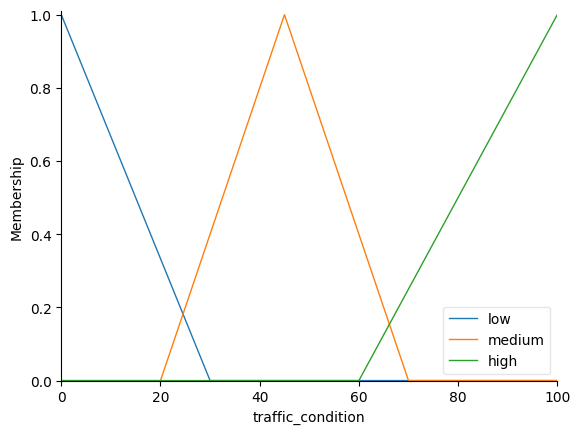

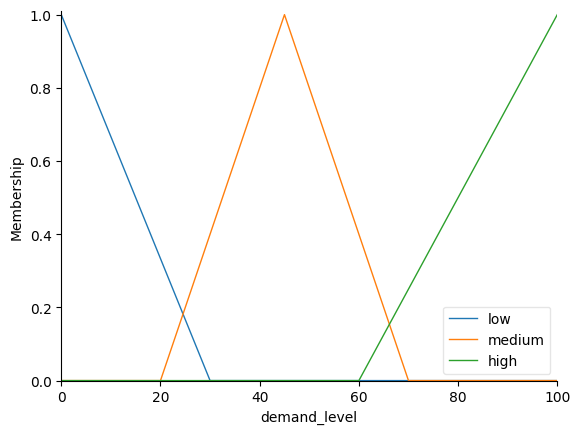

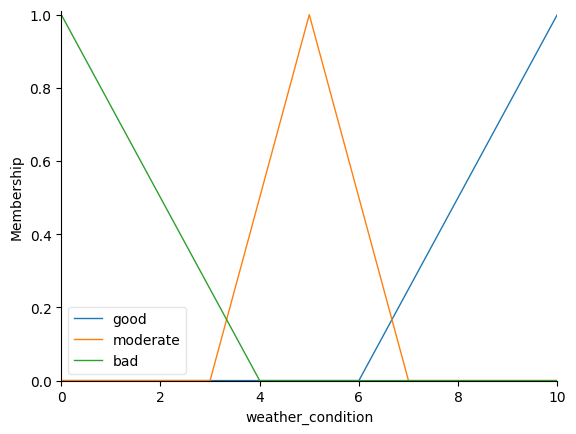

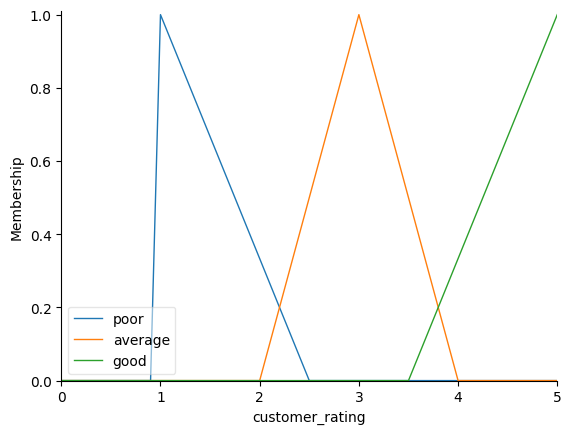

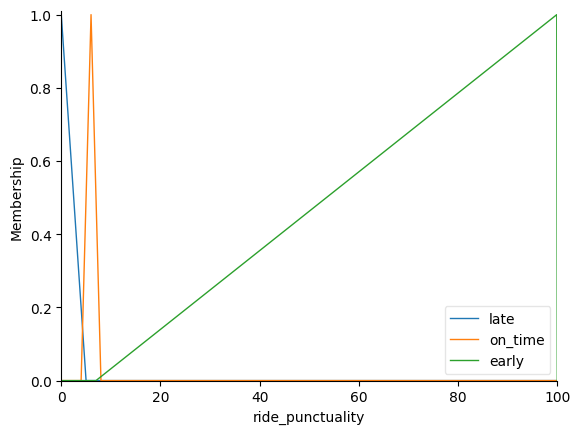

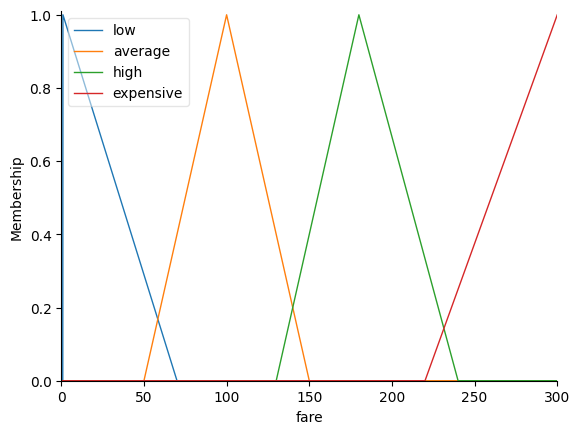

In [22]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
ride_distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'ride_distance')
traffic_condition = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'traffic_condition')
demand_level = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'demand_level')
weather_condition = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'weather_condition')
customer_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'customer_rating')
ride_punctuality = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'ride_punctuality')
fare = ctrl.Consequent(np.arange(0, 300.1, 0.1), 'fare')
loyalty_points = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'loyalty_points')
ride_distance['short']=fuzz.trimf(ride_distance.universe, [0, 0, 3])
ride_distance['medium']=fuzz.trimf(ride_distance.universe, [2, 5, 8])
ride_distance['long']=fuzz.trimf(ride_distance.universe,[6,15,20])
ride_distance['extreme']=fuzz.trimf(ride_distance.universe,[15,49,50])
ride_distance.view()
traffic_condition['low']=fuzz.trimf(traffic_condition.universe, [0, 0, 30])
traffic_condition['medium']=fuzz.trimf(traffic_condition.universe, [20, 45, 70])
traffic_condition['high']=fuzz.trimf(traffic_condition.universe,[60,100,100])
traffic_condition.view()
demand_level['low']=fuzz.trimf(demand_level.universe, [0, 0, 30])
demand_level['medium']=fuzz.trimf(demand_level.universe, [20, 45, 70])
demand_level['high']=fuzz.trimf(demand_level.universe,[60,100,100])
demand_level.view()
weather_condition['good']=fuzz.trimf(weather_condition.universe, [6, 10, 10])
weather_condition['moderate']=fuzz.trimf(weather_condition.universe, [3, 5, 7])
weather_condition['bad']=fuzz.trimf(weather_condition.universe,[0,0,4])
weather_condition.view()
customer_rating['poor']=fuzz.trimf(customer_rating.universe, [1, 1, 2.5])
customer_rating['average']=fuzz.trimf(customer_rating.universe, [2, 3, 4])
customer_rating['good']=fuzz.trimf(customer_rating.universe,[3.5,5,5])
customer_rating.view()
ride_punctuality['late']=fuzz.trimf(ride_punctuality.universe, [0, 0, 5])
ride_punctuality['on_time']=fuzz.trimf(ride_punctuality.universe, [4, 6, 8])
ride_punctuality['early']=fuzz.trimf(ride_punctuality.universe,[7,99.9,100])
ride_punctuality.view()
ride_punctuality['late']=fuzz.trimf(ride_punctuality.universe, [0, 0, 5])
ride_punctuality['on_time']=fuzz.trimf(ride_punctuality.universe, [4, 6, 8])
ride_punctuality['early']=fuzz.trimf(ride_punctuality.universe,[7,99.9,100])
fare['low']=fuzz.trimf(fare.universe, [1, 1, 70])
fare['average']=fuzz.trimf(fare.universe, [50,100,150])
fare['high']=fuzz.trimf(fare.universe,[130,180,240])
fare['expensive']=fuzz.trimf(fare.universe,[220,300,300])
fare.view()
loyalty_points['none']=fuzz.trimf(loyalty_points.universe, [0, 0, 1])
loyalty_points['low']=fuzz.trimf(loyalty_points.universe, [0.2,2,4])
loyalty_points['medium']=fuzz.trimf(loyalty_points.universe,[3,5,7])
loyalty_points['high']=fuzz.trimf(loyalty_points.universe,[6,9.9,10])

23.966666666666754
0.34444444444444444


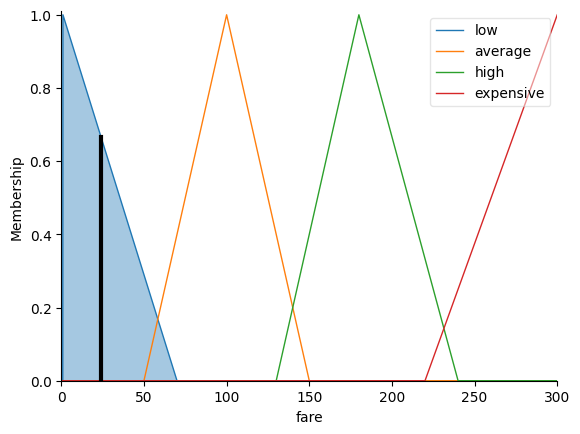

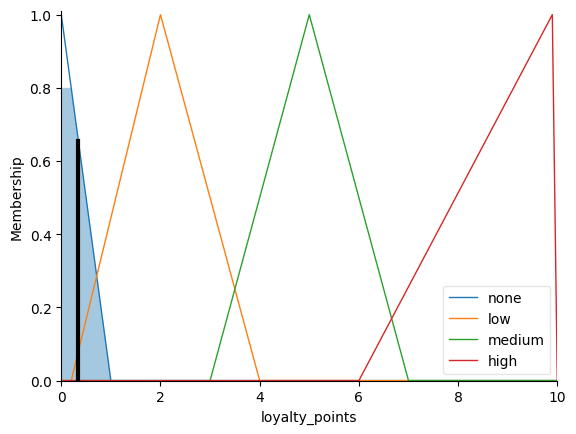

In [24]:
rule1 = ctrl.Rule(ride_distance['short'] & traffic_condition['low'] & demand_level['low'], fare['low'])
rule2 = ctrl.Rule(ride_distance['short'] & traffic_condition['medium'] & demand_level['high'], fare['average'])
rule3 = ctrl.Rule(ride_distance['medium'] & traffic_condition['high'] & demand_level['high'], fare['high'])
rule4 = ctrl.Rule(ride_distance['long'] & traffic_condition['medium'] & weather_condition['good'], fare['average'])
rule5 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & weather_condition['bad'], fare['high'])
rule6 = ctrl.Rule(ride_distance['extreme'] & traffic_condition['high'] & demand_level['high'], fare['expensive'])
rule7 = ctrl.Rule(ride_distance['medium'] & traffic_condition['low'] & demand_level['low'], fare['low'])
rule9 = ctrl.Rule(ride_distance['extreme'] & traffic_condition['high'] & weather_condition['bad'], fare['high'])
rule10 = ctrl.Rule(ride_distance['extreme'] & weather_condition['bad'], fare['expensive'])
rule11 = ctrl.Rule(customer_rating['good'] & ride_punctuality['early'], loyalty_points['high'])
rule12 = ctrl.Rule(customer_rating['average'] & ride_punctuality['on_time'], loyalty_points['medium'])
rule13 = ctrl.Rule(customer_rating['poor'] & ride_punctuality['late'], loyalty_points['none'])
rule14 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & ride_punctuality['on_time'], loyalty_points['high'])
rule15 = ctrl.Rule(ride_distance['medium'] & traffic_condition['medium'] & customer_rating['good'], loyalty_points['medium'])
rule17 = ctrl.Rule(ride_distance['extreme'] & weather_condition['bad'] & customer_rating['good'], loyalty_points['high'])
rule18 = ctrl.Rule(ride_distance['short'] & customer_rating['average'] & ride_punctuality['on_time'], loyalty_points['low'])
rule19 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & ride_punctuality['late'], loyalty_points['low'])
rule20 = ctrl.Rule(ride_distance['medium'] & weather_condition['moderate'] & customer_rating['good'], loyalty_points['medium'])
faring_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule9, rule10])
faring = ctrl.ControlSystemSimulation(faring_ctrl)
faring.input['ride_distance']=0
faring.input['traffic_condition']=0
faring.input['demand_level']=0
faring.input['weather_condition']=0
faring.compute()
print(faring.output['fare'])
fare.view(sim=faring)
loyalty_ctrl = ctrl.ControlSystem([rule11, rule12, rule13, rule14, rule15, rule17, rule18, rule19, rule20])
loyalty = ctrl.ControlSystemSimulation(loyalty_ctrl)
loyalty.input['customer_rating']=1
loyalty.input['ride_punctuality']=1
loyalty.compute()
print(loyalty.output['loyalty_points'])
loyalty_points.view(sim=loyalty)

In [ ]:
Bài 2.12

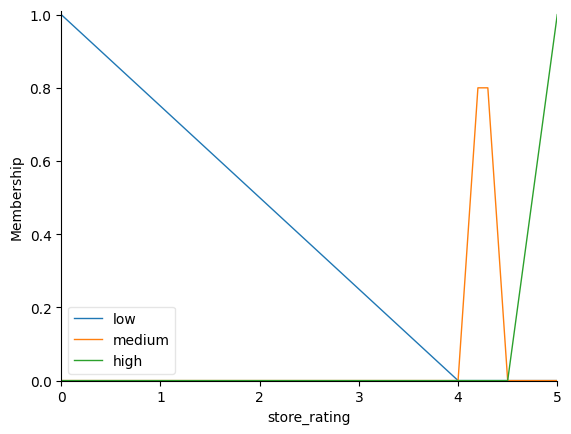

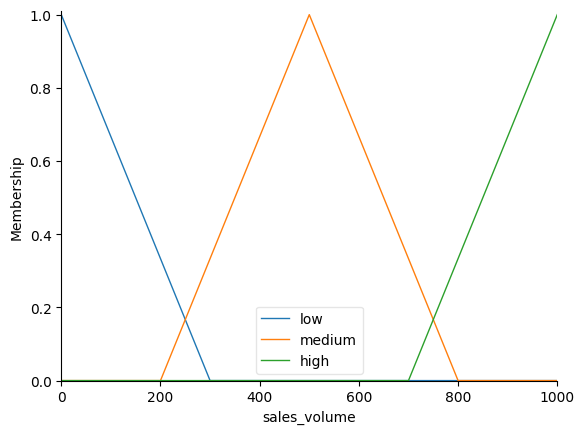

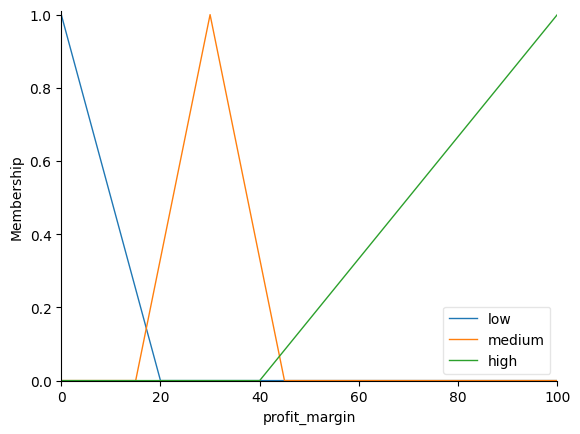

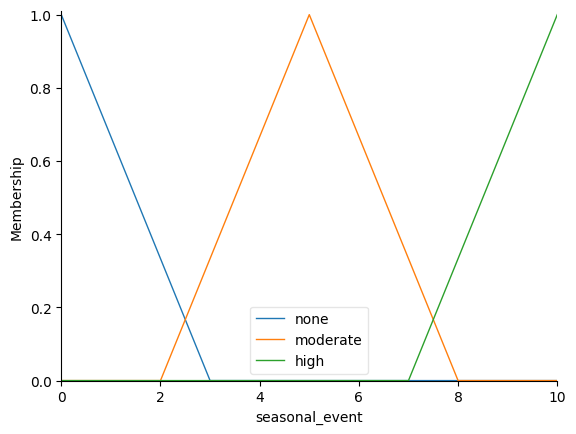

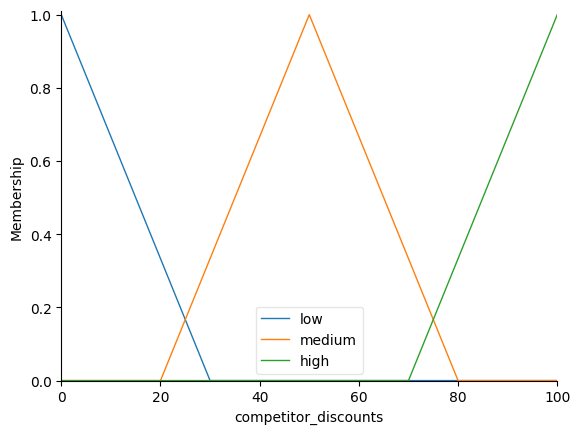

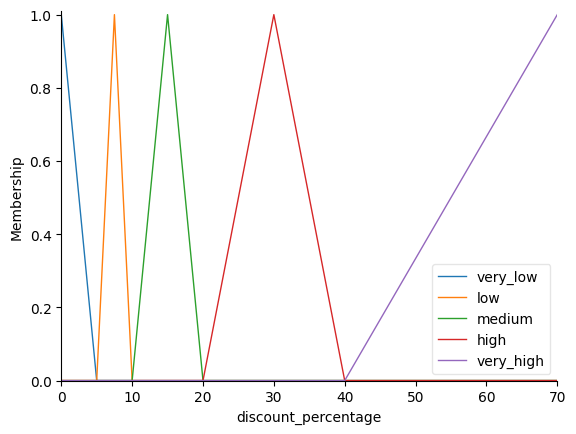

In [26]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 1001, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'seasonal_event')
competitor_discounts = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'competitor_discounts')
discount_percentage = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount_percentage')
store_rating['low'] = fuzz.trimf(store_rating.universe, [0, 0, 4.0])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [4.0, 4.25, 4.5])
store_rating['high'] = fuzz.trimf(store_rating.universe, [4.5, 5.0, 5.0])
store_rating.view()
sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 300])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [200, 500, 800])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [700, 1000, 1000])
sales_volume.view()
profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 20])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [15, 30, 45])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [40, 100, 100])
profit_margin.view()
seasonal_event['none'] = fuzz.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [7, 10, 10])
seasonal_event.view()
competitor_discounts['low'] = fuzz.trimf(competitor_discounts.universe, [0, 0, 30])
competitor_discounts['medium'] = fuzz.trimf(competitor_discounts.universe, [20, 50, 80])
competitor_discounts['high'] = fuzz.trimf(competitor_discounts.universe, [70, 100, 100])
competitor_discounts.view()
discount_percentage['very_low'] = fuzz.trimf(discount_percentage.universe, [0, 0, 5])
discount_percentage['low'] = fuzz.trimf(discount_percentage.universe, [5, 7.5, 10])
discount_percentage['medium'] = fuzz.trimf(discount_percentage.universe, [10, 15, 20])
discount_percentage['high'] = fuzz.trimf(discount_percentage.universe, [20, 30, 40])
discount_percentage['very_high'] = fuzz.trimf(discount_percentage.universe, [40, 70, 70])
discount_percentage.view()


57.333333333333286


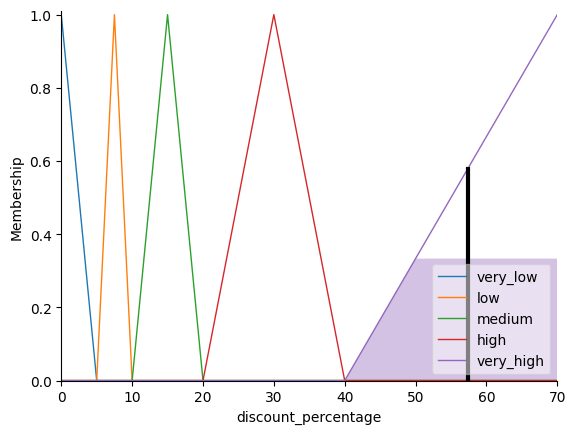

In [27]:
rule1 = ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount_percentage['very_low'])
rule2 = ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount_percentage['high'])
rule3 = ctrl.Rule(seasonal_event['high'] & competitor_discounts['high'], discount_percentage['very_high'])
rule4 = ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount_percentage['medium'])
rule5 = ctrl.Rule(competitor_discounts['low'] & profit_margin['low'] & sales_volume['high'], discount_percentage['very_low'])
rule6 = ctrl.Rule(store_rating['low'] & seasonal_event['none'], discount_percentage['medium'])
rule7 = ctrl.Rule(sales_volume['low'] & profit_margin['low'], discount_percentage['very_high'])
discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['store_rating'] = 4.3
discount_sim.input['sales_volume'] = 500
discount_sim.input['profit_margin'] = 15
discount_sim.input['seasonal_event'] = 9
discount_sim.input['competitor_discounts'] = 80
discount_sim.compute()
print(discount_sim.output['discount_percentage'])
discount_percentage.view(sim=discount_sim)

Bài 2.13

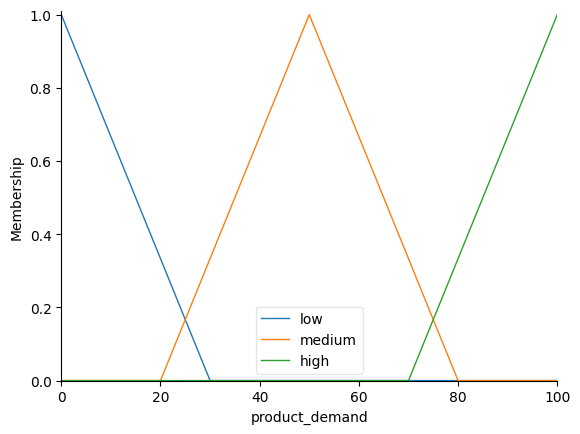

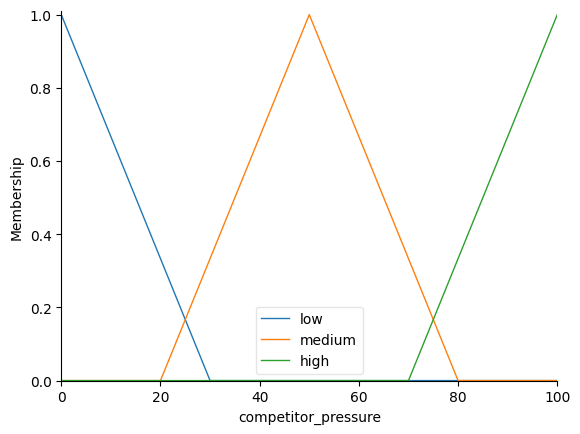

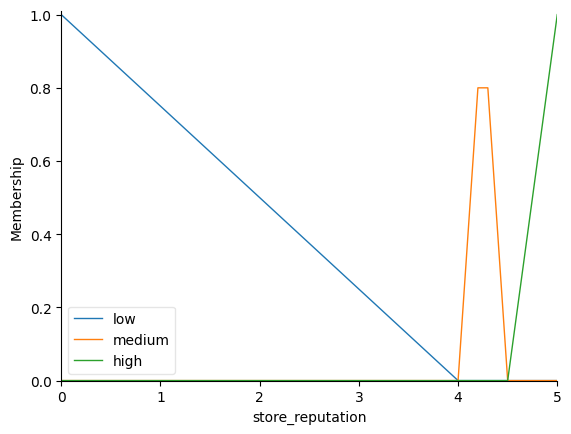

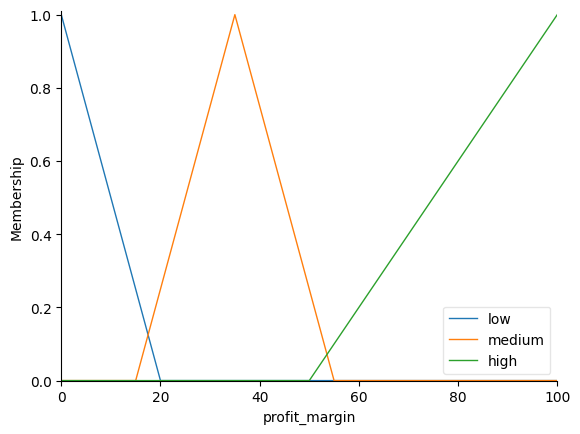

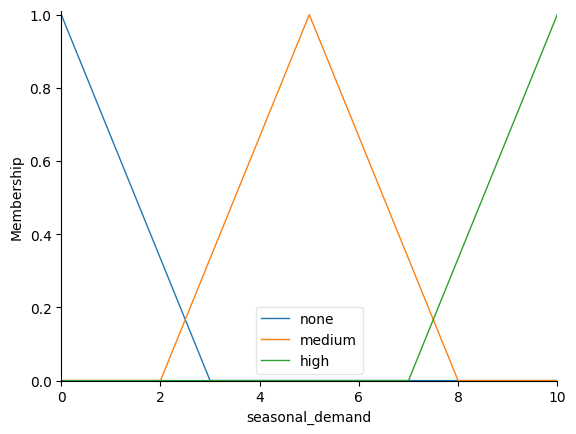

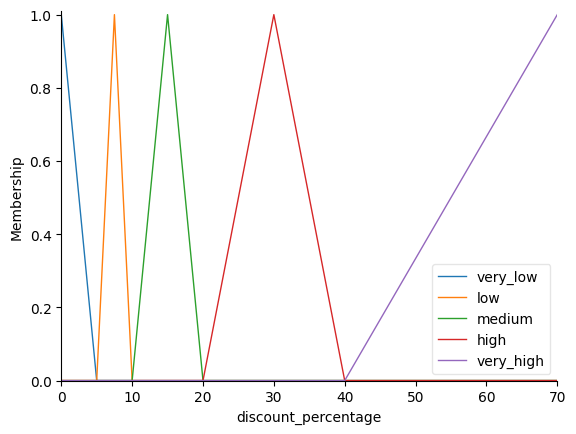

In [29]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
product_demand = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'product_demand')
competitor_pressure = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'competitor_pressure')
store_reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'seasonal_demand')
discount_percentage = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount_percentage')
product_demand['low'] = fuzz.trimf(product_demand.universe, [0, 0, 30])
product_demand['medium'] = fuzz.trimf(product_demand.universe, [20, 50, 80])
product_demand['high'] = fuzz.trimf(product_demand.universe, [70, 100, 100])
product_demand.view()
competitor_pressure['low'] = fuzz.trimf(competitor_pressure.universe, [0, 0, 30])
competitor_pressure['medium'] = fuzz.trimf(competitor_pressure.universe, [20, 50, 80])
competitor_pressure['high'] = fuzz.trimf(competitor_pressure.universe, [70, 100, 100])
competitor_pressure.view()
store_reputation['low'] = fuzz.trimf(store_reputation.universe, [0, 0, 4.0])
store_reputation['medium'] = fuzz.trimf(store_reputation.universe, [4.0, 4.25, 4.5])
store_reputation['high'] = fuzz.trimf(store_reputation.universe, [4.5, 5.0, 5.0])
store_reputation.view()
profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 20])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [15, 35, 55])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [50, 100, 100])
profit_margin.view()
seasonal_demand['none'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 3])
seasonal_demand['medium'] = fuzz.trimf(seasonal_demand.universe, [2, 5, 8])
seasonal_demand['high'] = fuzz.trimf(seasonal_demand.universe, [7, 10, 10])
seasonal_demand.view()
discount_percentage['very_low'] = fuzz.trimf(discount_percentage.universe, [0, 0, 5])
discount_percentage['low'] = fuzz.trimf(discount_percentage.universe, [5, 7.5, 10])
discount_percentage['medium'] = fuzz.trimf(discount_percentage.universe, [10, 15, 20])
discount_percentage['high'] = fuzz.trimf(discount_percentage.universe, [20, 30, 40])
discount_percentage['very_high'] = fuzz.trimf(discount_percentage.universe, [40, 70, 70])
discount_percentage.view()

15.000000000000004


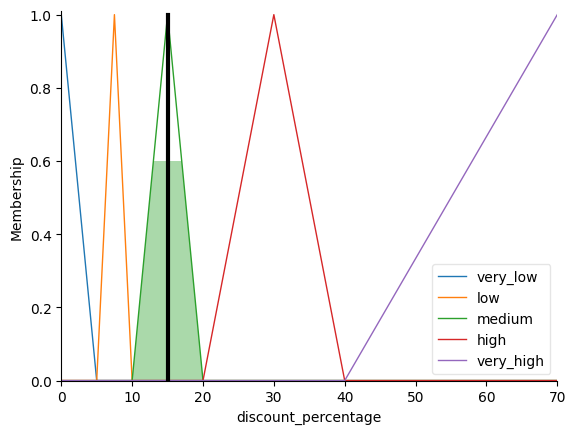

In [32]:
rule1 = ctrl.Rule(product_demand['high'] & competitor_pressure['low'] & profit_margin['low'], discount_percentage['very_low'])
rule2 = ctrl.Rule(product_demand['low'] & competitor_pressure['high'] & profit_margin['high'], discount_percentage['high'])
rule3 = ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount_percentage['medium'])
rule4 = ctrl.Rule(competitor_pressure['high'] & seasonal_demand['high'] & profit_margin['high'], discount_percentage['very_high'])
rule5 = ctrl.Rule(store_reputation['low'] & product_demand['medium'] & profit_margin['low'], discount_percentage['medium'])
rule6 = ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & competitor_pressure['low'], discount_percentage['very_low'])
rule7 = ctrl.Rule(profit_margin['high'] & competitor_pressure['medium'] & seasonal_demand['high'], discount_percentage['medium'])
discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount = ctrl.ControlSystemSimulation(discount_ctrl)
discount.input['product_demand'] = 90
discount.input['competitor_pressure'] = 50
discount.input['store_reputation'] = 4.2
discount.input['profit_margin'] = 80
discount.input['seasonal_demand'] = 9
discount.compute()
print(discount.output['discount_percentage'])
discount_percentage.view(sim=discount)

Bài 2.14

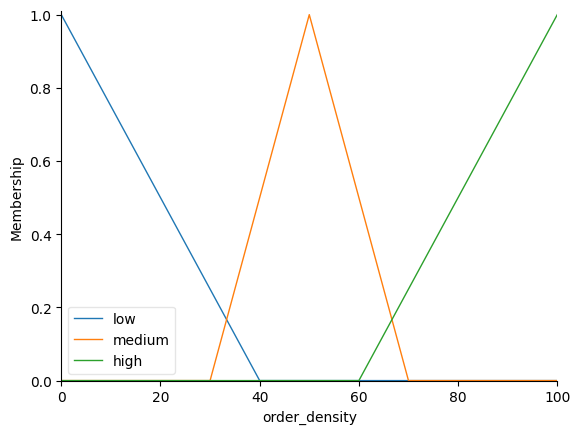

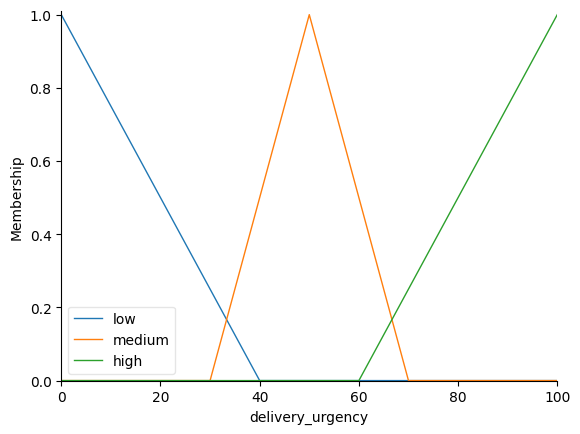

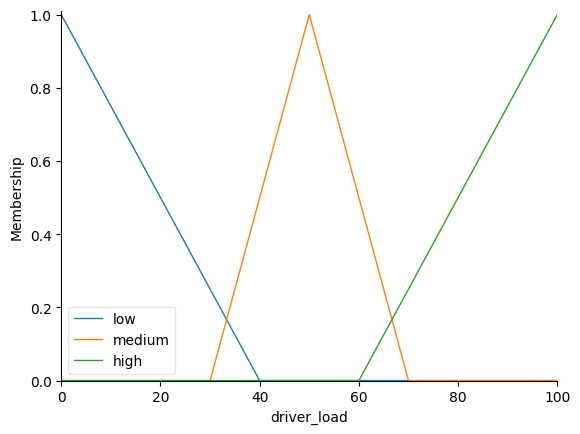

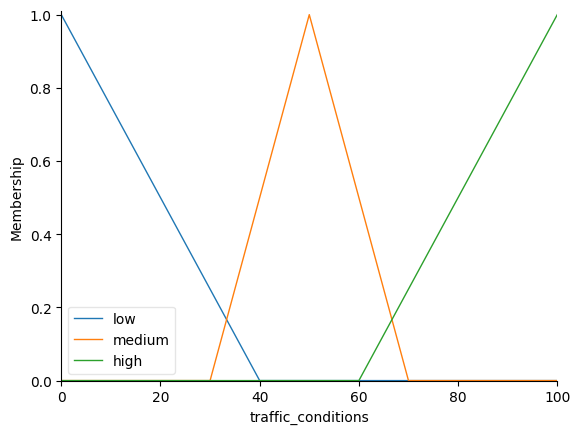

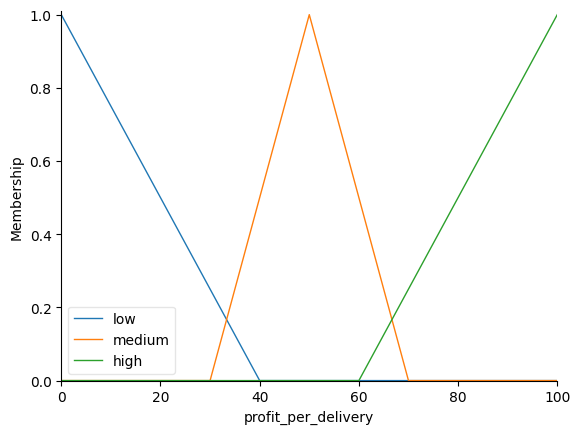

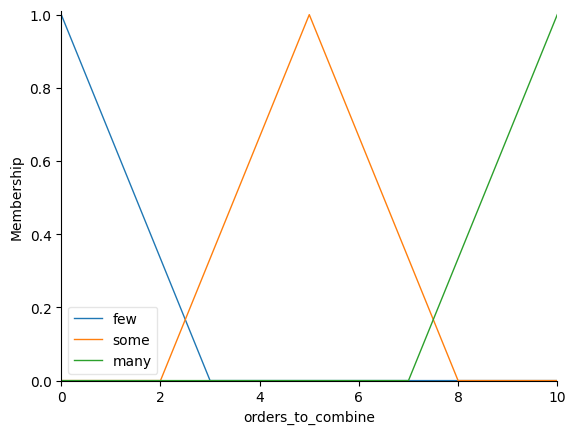

In [35]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic_conditions = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_conditions')
profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')
orders_to_combine = ctrl.Consequent(np.arange(0, 11, 1), 'orders_to_combine')
delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')
order_density['low'] = fuzz.trimf(order_density.universe, [0, 0, 40])
order_density['medium'] = fuzz.trimf(order_density.universe, [30, 50, 70])
order_density['high'] = fuzz.trimf(order_density.universe, [60, 100, 100])
order_density.view()
delivery_urgency['low'] = fuzz.trimf(delivery_urgency.universe, [0, 0, 40])
delivery_urgency['medium'] = fuzz.trimf(delivery_urgency.universe, [30, 50, 70])
delivery_urgency['high'] = fuzz.trimf(delivery_urgency.universe, [60, 100, 100])
delivery_urgency.view()
driver_load['low'] = fuzz.trimf(driver_load.universe, [0, 0, 40])
driver_load['medium'] = fuzz.trimf(driver_load.universe, [30, 50, 70])
driver_load['high'] = fuzz.trimf(driver_load.universe, [60, 100, 100])
driver_load.view()
traffic_conditions['low'] = fuzz.trimf(traffic_conditions.universe, [0, 0, 40])
traffic_conditions['medium'] = fuzz.trimf(traffic_conditions.universe, [30, 50, 70])
traffic_conditions['high'] = fuzz.trimf(traffic_conditions.universe, [60, 100, 100])
traffic_conditions.view()
profit_per_delivery['low'] = fuzz.trimf(profit_per_delivery.universe, [0, 0, 40])
profit_per_delivery['medium'] = fuzz.trimf(profit_per_delivery.universe, [30, 50, 70])
profit_per_delivery['high'] = fuzz.trimf(profit_per_delivery.universe, [60, 100, 100])
profit_per_delivery.view()
orders_to_combine['few'] = fuzz.trimf(orders_to_combine.universe, [0, 0, 3])
orders_to_combine['some'] = fuzz.trimf(orders_to_combine.universe, [2, 5, 8])
orders_to_combine['many'] = fuzz.trimf(orders_to_combine.universe, [7, 10, 10])
orders_to_combine.view()
delivery_priority['low'] = fuzz.trimf(delivery_priority.universe, [0, 0, 40])
delivery_priority['medium'] = fuzz.trimf(delivery_priority.universe, [30, 50, 70])
delivery_priority['high'] = fuzz.trimf(delivery_priority.universe, [60, 100, 100])



Số lượng đơn hàng cần kết hợp: 8.833333333333334
Mức độ ưu tiên giao hàng: 49.99999999999999


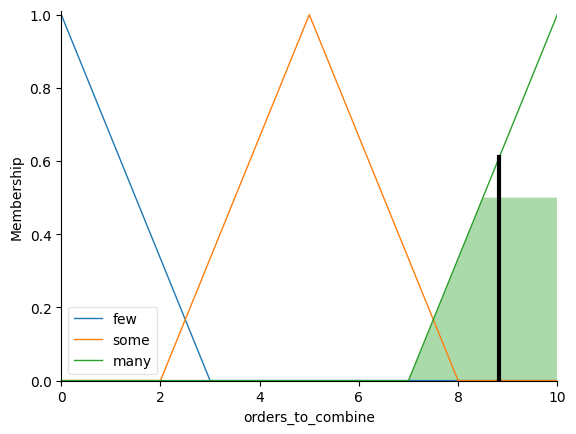

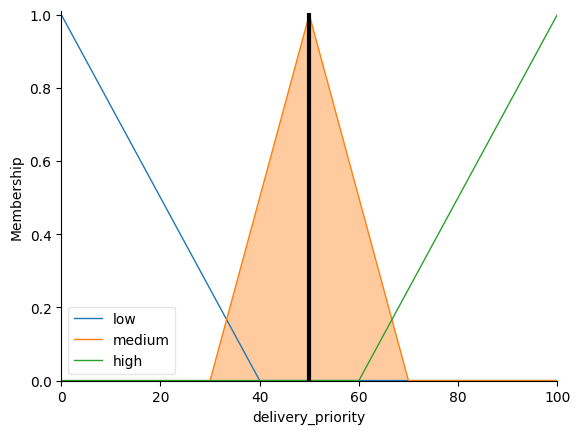

In [37]:
rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic_conditions['medium'], orders_to_combine['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic_conditions['high'] & delivery_urgency['medium'], orders_to_combine['some'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit_per_delivery['medium'], orders_to_combine['some'])
rule4 = ctrl.Rule(order_density['low'] & delivery_urgency['high'] & traffic_conditions['medium'], orders_to_combine['some'])
rule5 = ctrl.Rule(profit_per_delivery['high'] & delivery_urgency['high'] & traffic_conditions['high'], orders_to_combine['some'])
rule6 = ctrl.Rule(delivery_urgency['high'] & profit_per_delivery['high'], delivery_priority['high'])
rule7 = ctrl.Rule(delivery_urgency['medium'] & traffic_conditions['medium'], delivery_priority['medium'])
rule8 = ctrl.Rule(delivery_urgency['low'] & order_density['high'] & profit_per_delivery['low'], delivery_priority['low'])
combine_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
priority_ctrl = ctrl.ControlSystem([rule6, rule7, rule8])
combine_sim = ctrl.ControlSystemSimulation(combine_ctrl)
priority_sim = ctrl.ControlSystemSimulation(priority_ctrl)
input_density = 90
input_urgency = 50
input_load = 20
input_traffic = 50
input_profit = 50
combine_sim.input['order_density'] = input_density
combine_sim.input['driver_load'] = input_load
combine_sim.input['traffic_conditions'] = input_traffic
combine_sim.input['delivery_urgency'] = input_urgency
combine_sim.input['profit_per_delivery'] = input_profit
priority_sim.input['delivery_urgency'] = input_urgency
priority_sim.input['profit_per_delivery'] = input_profit
priority_sim.input['traffic_conditions'] = input_traffic
priority_sim.input['order_density'] = input_density
combine_sim.compute()
priority_sim.compute()
print("Số lượng đơn hàng cần kết hợp:", combine_sim.output['orders_to_combine'])
print("Mức độ ưu tiên giao hàng:", priority_sim.output['delivery_priority'])
orders_to_combine.view(sim=combine_sim)
delivery_priority.view(sim=priority_sim)